In [1]:
import time
import random
import matplotlib.pyplot as plt

# Conventional Matrix Multiplication

def matrix_multiply(A, B):

    n = len(A)

    C = [[0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]

    return C

#Strassen's Matrix Multiplication

def add_matrix(A, B):
    n = len(A)

    return [
        [A[i][j] + B[i][j] for j in range(n)]
        for i in range(n)
    ]


def subtract_matrix(A, B):
    n = len(A)

    return [
        [A[i][j] - B[i][j] for j in range(n)]
        for i in range(n)
    ]


def strassen(A, B):

    n = len(A)

    # Base case
    if n == 1:
        return [[A[0][0] * B[0][0]]]

    mid = n // 2

    # Divide A
    A11 = [row[:mid] for row in A[:mid]]
    A12 = [row[mid:] for row in A[:mid]]
    A21 = [row[:mid] for row in A[mid:]]
    A22 = [row[mid:] for row in A[mid:]]

    # Divide B
    B11 = [row[:mid] for row in B[:mid]]
    B12 = [row[mid:] for row in B[:mid]]
    B21 = [row[:mid] for row in B[mid:]]
    B22 = [row[mid:] for row in B[mid:]]

    # Seven Strassen products
    M1 = strassen(
        add_matrix(A11, A22),
        add_matrix(B11, B22)
    )

    M2 = strassen(
        add_matrix(A21, A22),
        B11
    )

    M3 = strassen(
        A11,
        subtract_matrix(B12, B22)
    )

    M4 = strassen(
        A22,
        subtract_matrix(B21, B11)
    )

    M5 = strassen(
        add_matrix(A11, A12),
        B22
    )

    M6 = strassen(
        subtract_matrix(A21, A11),
        add_matrix(B11, B12)
    )

    M7 = strassen(
        subtract_matrix(A12, A22),
        add_matrix(B21, B22)
    )

    # Calculate result quadrants
    C11 = add_matrix(
        subtract_matrix(
            add_matrix(M1, M4),
            M5
        ),
        M7
    )

    C12 = add_matrix(M3, M5)

    C21 = add_matrix(M2, M4)

    C22 = add_matrix(
        subtract_matrix(
            add_matrix(M1, M3),
            M2
        ),
        M6
    )

    # Combine quadrants
    C = []

    for i in range(mid):
        C.append(C11[i] + C12[i])

    for i in range(mid):
        C.append(C21[i] + C22[i])

    return C



# Generate fixed matrices

def generate_matrix(n):
    return [
        [random.randint(1, 10) for _ in range(n)]
        for _ in range(n)
    ]


# -----------------------------------
# Input sizes
# Powers of 2 are used because
# Strassen divides matrices in half.
# -----------------------------------

sizes = [2, 4, 8, 16, 32, 64, 128]

runs = 5

conventional_times = []
strassen_times = []


for n in sizes:

    # Generate ONCE
    A = generate_matrix(n)
    B = generate_matrix(n)

    conventional_measurements = []
    strassen_measurements = []

    for _ in range(runs):

        # Conventional multiplication
        start = time.perf_counter_ns()

        matrix_multiply(A, B)

        end = time.perf_counter_ns()

        conventional_measurements.append(end - start)


        # Strassen multiplication
        start = time.perf_counter_ns()

        strassen(A, B)

        end = time.perf_counter_ns()

        strassen_measurements.append(end - start)

    conventional_times.append(
        sum(conventional_measurements) / runs
    )

    strassen_times.append(
        sum(strassen_measurements) / runs
    )

    print(f"n = {n} completed")

n = 2 completed
n = 4 completed
n = 8 completed
n = 16 completed
n = 32 completed
n = 64 completed
n = 128 completed


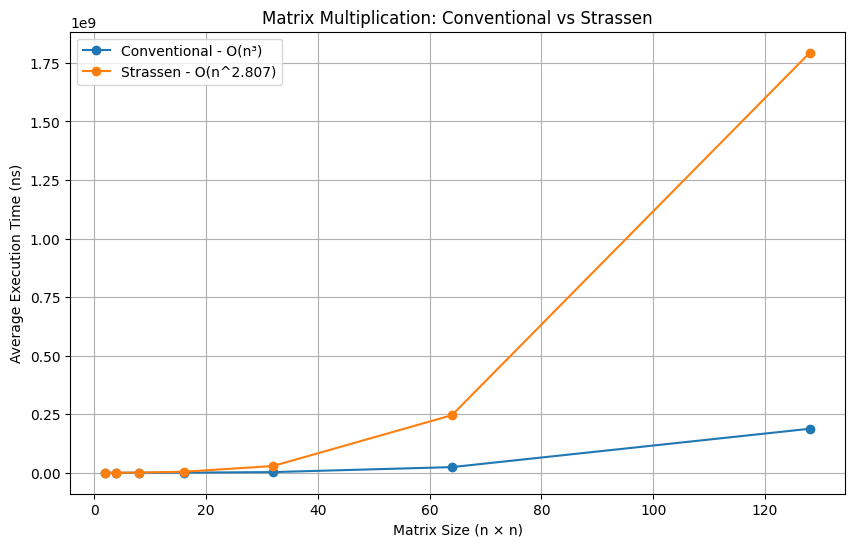

In [2]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    conventional_times,
    marker='o',
    label='Conventional - O(n³)'
)

plt.plot(
    sizes,
    strassen_times,
    marker='o',
    label="Strassen - O(n^2.807)"
)

plt.xlabel("Matrix Size (n × n)")
plt.ylabel("Average Execution Time (ns)")
plt.title("Matrix Multiplication: Conventional vs Strassen")
plt.legend()
plt.grid(True)

plt.show()